# Aligning MSI onto classic Visium (Space Ranger, not Visium HD)

This is the classic-Visium counterpart to `examples/l12_direct_to_visium.ipynb`: same direct
alignment idea (MSI grid registered straight onto the Visium H&E image, no separate MSI-H&E
step), but reading a standard Space Ranger `outs/` folder via `spatialdata_io.visium(...)`
instead of `visium_hd(...)`.

**A wrinkle specific to this dataset:** this Space Ranger run didn't save a full-resolution
H&E image, only the downscaled `tissue_hires_image.png` / `tissue_lowres_image.png` preview
images. Spot coordinates (`obsm['spatial']`) are recorded in full-resolution pixel space by
Space Ranger regardless, so they don't natively match either preview image's pixel grid. Step 1
below rescales them into the hires image's own pixel space using the same scale factor Space
Ranger itself records (`scalefactors_json.json`'s `tissue_hires_scalef`) -- once that's done,
the rest of the notebook treats it like any other image + points SpatialData object.

There's also no MSI H&E image for this dataset (only the MSI instrument's raw CSV exports), so
just like `l12_direct_to_visium.ipynb`, the MSI grid is registered directly against the Visium
H&E image rather than against an intermediate MSI-section H&E.

In [1]:
import sys
sys.path.insert(0, "msi")  # examples/msi/ contains msi_loader.py (MSI vendor CSV parsing)

import numpy as np
import spatialdata as sd
from spatialdata import SpatialData
from spatialdata.models import Image2DModel
from msi_loader import MSIdata

import spatialdata_io
import spatialwarp as sw

/home/croizer/.local/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/croizer/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/croizer/.local/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


A couple of steps below open a window where you click points with your mouse. For that to
work in Jupyter, run this cell first to switch to a real window backend instead of the default
static-image mode (`tk` works out of the box with no extra install; use `qt` instead if you
have PyQt5/PySide installed and prefer it).

In [2]:
%matplotlib tk

## Step 1 -- Load the classic Visium data, and fix up its pixel space

`spatialdata_io.visium(...)` reads the Space Ranger `outs/` folder. Without a
`fullres_image_file` (none exists for this sample), the images it loads (`*_hires_image`,
`*_lowres_image`) are downscaled previews that don't match `obsm['spatial']`'s full-resolution
pixel space. We rescale the table's coordinates into the hires image's pixel space using
Space Ranger's own `downscaled_hires` scale factor, then repackage as a plain image + points
`SpatialData` object -- same shape every other object in this pipeline has.

In [4]:
visium_path = "/home/croizer/Documents/01_Ressources/01_GENIAL_pilote/RNAdata/ST/D1225/outs"

visium_raw_sdata = spatialdata_io.visium(visium_path, dataset_id="D1225")

hires_key = "D1225_hires_image"
shapes_key = "D1225"
hires_scale = sd.transformations.get_transformation(visium_raw_sdata.shapes[shapes_key], "downscaled_hires").scale[0]

visium_hires_array = sw.extract_image(visium_raw_sdata, key=hires_key)
visium_table = visium_raw_sdata.tables["table"].copy()
visium_table.obsm["spatial"] = visium_table.obsm["spatial"] * hires_scale

visium_sdata = SpatialData(
    images={"he": Image2DModel.parse(np.moveaxis(np.atleast_3d(visium_hires_array), -1, 0))},
    tables={"visium": visium_table},
)
visium_sdata

INFO     reading                                                                                                   
         /home/croizer/Documents/01_Ressources/01_GENIAL_pilote/RNAdata/ST/D1225/outs/filtered_feature_bc_matrix.h5


/home/croizer/miniconda3/envs/msi/lib/python3.13/site-packages/spatialdata/models/models.py:1035: UserWarning: Converting `region_key: region` to categorical dtype.
  return convert_region_column_to_categorical(adata)


INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           


/home/croizer/miniconda3/envs/msi/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:158: UserWarning: The table is annotating 'D1225', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


SpatialData object
├── Images
│     └── 'he': DataArray[cyx] (3, 1801, 2000)
└── Tables
      └── 'visium': AnnData (3065, 38479)
with coordinate systems:
    ▸ 'global', with elements:
        he (Images)

## Step 2 -- Load the MSI metabolomics data (points + features only)

No MSI H&E image is used at all in this workflow -- only the MSI instrument's own CSV exports
(counts, metabolite library, spot coordinates).

In [5]:
count_path = "/home/croizer/Documents/01_Ressources/01_GENIAL_pilote/MSIdata/MSI/SCiLS Exports/Counts/20231027-SMEC018-2-Raw.csv"
total_ion_path = "/home/croizer/Documents/01_Ressources/01_GENIAL_pilote/MSIdata/MSI/SCiLS Exports/Counts/20231027-SMEC018-2-Total Ion Count.csv"
metabolite_path = "/home/croizer/Documents/01_Ressources/01_GENIAL_pilote/MSIdata/MSI/SCiLS Exports/MetaboliteLibrary/corrected_metabolites.csv"
coordinates_path = "/home/croizer/Documents/01_Ressources/01_GENIAL_pilote/MSIdata/MSI/SCiLS Exports/SpotCoordinates/20231027-SMEC018-2-Spots.csv"

# Total-Ion-Count-normalized intensities (rather than count_path's raw, un-normalized export)
# -- same normalization choice examples/l12_walkthrough.ipynb makes.
msi_metabo = MSIdata(total_ion_path, metabolite_path, coordinates_path)
metabo_counts = msi_metabo.get_count_formated()
metabo_points_xy = msi_metabo.coordinates[["x", "y"]].values.astype(float)
metabo_features = metabo_counts.drop(columns=["x", "y"])

print("metabo_points_xy:", metabo_points_xy.shape, " features:", metabo_features.shape)

metabo_points_xy: (16418, 2)  features: (16418, 81)


## Step 3 -- Align the MSI grid directly onto the Visium H&E image

`sw.build_spatialdata(...)` packages the *raw* MSI points against `visium_hires_array` as the
reference image (rather than a separate MSI H&E image). `sw.align_grid(...)` then rasterizes the
points and registers that pseudo-image straight against it: click a point on the Visium H&E
(left), then its match on the rasterized MSI preview (right), for ~5-10 landmarks (use the
feature browser buttons if summed intensity isn't the clearest picture), then close the window.

In [6]:
msi_metabo_raw_sdata = sw.build_spatialdata(
    visium_hires_array, metabo_points_xy, values=metabo_features, image_key="he", table_key="msi"
)

msi_metabo_sdata = sw.align_grid(
    msi_metabo_raw_sdata,
    image_key="he",
    table_key="msi",
    output_csv="transformed_coordinates_D1225_metabo.csv",
    mesh_size=(8, 8),
    number_of_iterations=100,
)
msi_metabo_sdata

INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           


can't invoke "event" command: application has been destroyed
    while executing
"event generate $w <<ThemeChanged>>"
    (procedure "ttk::ThemeChanged" line 6)
    invoked from within
"ttk::ThemeChanged"


SpatialData object
├── Images
│     └── 'he': DataArray[cyx] (3, 1801, 2000)
└── Tables
      └── 'msi': AnnData (16418, 81)
with coordinate systems:
    ▸ 'global', with elements:
        he (Images)

**Check it worked:** the plot below overlays the aligned MSI spots on the Visium H&E image.
Drag the alpha slider: the colored spots should trace out real tissue features, not float off
to one side. If the MSI grid comes out mirrored relative to the tissue (a vendor coordinate
quirk seen on some instruments, e.g. in `l12_walkthrough.ipynb`), re-run Step 2 with
`metabo_points_xy[:, 0] = metabo_points_xy[:, 0].max() - metabo_points_xy[:, 0]` added before
Step 3 and try again.

In [7]:
msi_metabo_table = msi_metabo_sdata.tables["msi"]
sw.plot_overlay(
    image=visium_hires_array,
    points_xy=msi_metabo_table.obsm["spatial"],
    values=msi_metabo_table.X.sum(axis=1),
)

invalid command name "131902475134208process_stream_events"
    while executing
"131902475134208process_stream_events"
    ("after" script)
can't invoke "event" command: application has been destroyed
    while executing
"event generate $w <<ThemeChanged>>"
    (procedure "ttk::ThemeChanged" line 6)
    invoked from within
"ttk::ThemeChanged"


(<Figure size 1000x1000 with 2 Axes>,
 <Axes: title={'center': 'Alignment QC — drag the slider to inspect overlap'}>)

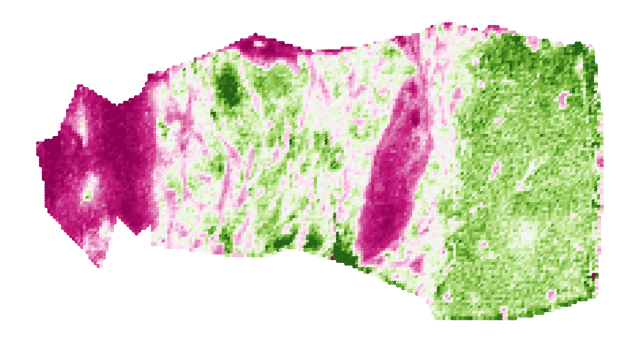

In [46]:
feature = "Linoleic acid"

values = metabo_features[feature].values.astype(float)
vmin, vmax = np.nanpercentile(values, [1, 99])

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(
    metabo_points_xy[:, 0], metabo_points_xy[:, 1],
    c=values, cmap="PiYG", vmin=vmin, vmax=vmax, s=4,
)
ax.set_aspect("equal")
ax.invert_yaxis()
ax.axis("off")
plt.show()


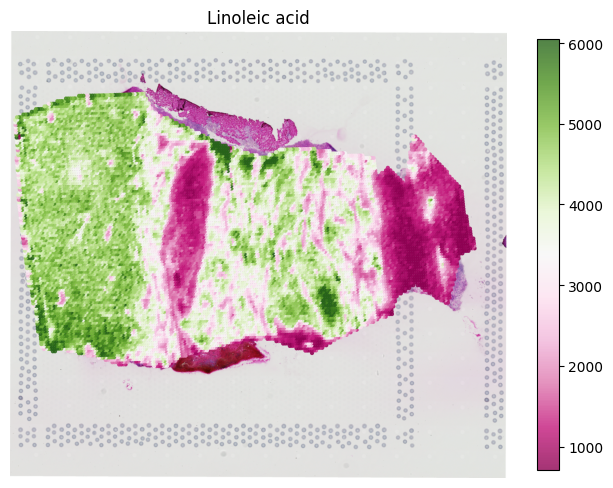

In [42]:
feature = "Linoleic acid"

msi_metabo_table = msi_metabo_sdata.tables["msi"]
values = np.asarray(msi_metabo_table[:, feature].X).ravel()
spatial_coords = msi_metabo_table.obsm["spatial"]

vmin, vmax = np.nanpercentile(values, [1, 99])

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(visium_hires_array)
sca = ax.scatter(
    spatial_coords[:, 0], spatial_coords[:, 1],
    c=values, cmap="PiYG", vmin=vmin, vmax=vmax, s=4, alpha=0.8,
)
ax.set_title(feature)
ax.set_aspect("equal")
ax.axis("off")
plt.colorbar(sca, ax=ax, shrink=0.7)
plt.show()


## Step 4 -- Match against Visium spots (no further registration needed)

`msi_metabo_sdata`'s points are already expressed in the Visium H&E's own pixel space (Step 3
registered directly against `visium_hires_array`, the same image `visium_sdata` was built from),
so `already_aligned=True` skips `sw.align()`'s own registration step and goes straight to
nearest-neighbor matching + merging. `distance_threshold` is in hires-image pixels here (not
full-resolution pixels) -- classic Visium's ~55um spot pitch is a few hires pixels wide at this
scale factor, so start small and loosen it if too few spots match.

In [8]:
adata_metabo = sw.align(
    moving=msi_metabo_sdata,
    fixed=visium_sdata,
    already_aligned=True,
    distance_threshold=15.0,
    fixed_table_key="visium",
    moving_obsm_key="metabolite",
)
print(f"kept {adata_metabo.n_obs} of {visium_sdata.tables['visium'].n_obs} Visium spots")
adata_metabo

kept 2850 of 3065 Visium spots


AnnData object with n_obs × n_vars = 2850 × 38479
    obs: 'in_tissue', 'array_row', 'array_col', 'spot_id', 'region', 'nearest_index', 'nearest_distance'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'spatialdata_attrs', 'spatialwarp'
    obsm: 'spatial', 'spatial_warped', 'metabolite'

`adata_metabo` is now a regular Visium `AnnData` object with gene expression as usual, plus the
matched metabolite intensities in `adata_metabo.obsm["metabolite"]`.

The plot below is a final visual sanity check: it shows which Visium spots were kept after the
distance filter. It should trace out the tissue shape, not a scattered cloud or a near-empty
plot (which would mean `distance_threshold` needs loosening, or the alignment in Step 3 needs
more/better-placed landmarks).

In [9]:
import matplotlib.pyplot as plt

plt.scatter(*adata_metabo.obsm["spatial_warped"].T, s=4, alpha=0.4)
plt.gca().invert_yaxis()
plt.gca().set_aspect("equal")
plt.title("Visium spots kept after MSI distance filter")
plt.show()

## Step 5 -- Transfer the same alignment onto a BayesSpace-enhanced grid

`aligned_msi_visium_enhanced.h5ad` is D1225's Visium data after BayesSpace's `enhanceFeatures()`
(run outside this package, in R): each of the 3065 original spots is subdivided into 6
sub-spots (18,390 total), with spatially-smoothed gene expression predicted at that finer
resolution. It has `msi_<metabolite>` columns already baked in from an earlier, separate test --
drop those; what we want here is to reuse *this notebook's own* registration (Steps 2-3) instead.

Since registration only depends on the two images (MSI raster vs. `visium_hires_array`), not on
which grid of points gets matched against it, `msi_metabo_sdata` -- already aligned onto
`visium_hires_array`'s pixel space -- can be matched directly against the enhanced sub-spots
too, with `already_aligned=True` skipping registration entirely (exactly the same mechanism as
Step 4, just against a finer `fixed` grid). No new landmarks, no new elastic registration --
the metabolite measurements just get transferred onto BayesSpace's higher-resolution grid for
free.

`obsm['spatial']` in the enhanced file is in full-resolution pixel space (unrescaled, unlike
`visium_sdata`'s own table) -- rescale it with the same `hires_scale` from Step 1 before
wrapping it up the same way.

In [82]:
import pandas as pd

aligned_df = pd.read_csv("transformed_coordinates_D1225_metabo.csv")
aligned_xy = aligned_df[["x_transformed", "y_transformed"]].values

msi_metabo_sdata = sw.build_spatialdata(
    visium_hires_array, aligned_xy, values=metabo_features, image_key="he", table_key="msi"
)


INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           


In [83]:
import anndata as ad

visium_enhanced = ad.read_h5ad("/home/croizer/Documents/02_Analysis/01_MSI_analysis/aligned_msi_visium_enhanced.h5ad")

# drop the msi_* columns already in this file -- past test, not this notebook's own alignment
msi_cols_enhanced = [c for c in visium_enhanced.obs.columns if c.startswith("msi_")]
visium_enhanced.obs = visium_enhanced.obs.drop(columns=msi_cols_enhanced)

visium_enhanced.obsm["spatial"] = visium_enhanced.obsm["spatial"] * hires_scale

visium_enhanced_sdata = SpatialData(
    images={"he": Image2DModel.parse(np.moveaxis(np.atleast_3d(visium_hires_array), -1, 0))},
    tables={"visium_enhanced": visium_enhanced},
)
visium_enhanced_sdata

INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           


SpatialData object
├── Images
│     └── 'he': DataArray[cyx] (3, 1801, 2000)
└── Tables
      └── 'visium_enhanced': AnnData (18390, 38479)
with coordinate systems:
    ▸ 'global', with elements:
        he (Images)

In [95]:
adata_metabo_enhanced = sw.align(
    moving=msi_metabo_sdata,
    fixed=visium_enhanced_sdata,
    already_aligned=True,
    distance_threshold=5.0,
    fixed_table_key="visium_enhanced",
    moving_obsm_key="metabolite",
)
print(f"kept {adata_metabo_enhanced.n_obs} of {visium_enhanced_sdata.tables['visium_enhanced'].n_obs} enhanced sub-spots")
adata_metabo_enhanced

kept 13975 of 18390 enhanced sub-spots


AnnData object with n_obs × n_vars = 13975 × 38479
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'spot.idx', 'spot.neighbors', 'subspot.idx', 'subspot.neighbors', 'spot.row', 'spot.col', 'array_row', 'array_col', 'spot.pxl.row', 'spot.pxl.col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'spatial.cluster', 'nearest_index', 'nearest_distance'
    var: 'gene_id', 'gene_name', 'is.HVG', 'enhanceFeatures.rmse'
    uns: 'msi_metabolites', 'spatial', 'spatialwarp'
    obsm: 'X_PCA', 'spatial', 'spatial_warped', 'metabolite'

In [96]:
sorted(adata_metabo_enhanced.obsm['metabolite'].columns)

['(Iso)Citric acid',
 '1-(sn-Glycero-3-phospho)-1D-myo-inositol',
 '11-Eicosenoic acid',
 '2(3)-Phosphoglyceric acid',
 '2,3-Diphosphoglyceric acid',
 '4-Hydroxy-L-threonine',
 '6-Phosphogluconic acid',
 '6_8-Dihydroxypurine',
 '8,11,14-Eicosatrienoic acid',
 "Adenosine 3'_5'-diphosphate",
 'Adenosine monophosphate',
 'Adenosine triphosphate',
 'Adenylsuccinic acid',
 'Adrenic acid',
 'Arachidonic acid',
 'Asparagine',
 'Aspartic acid',
 'Aspartyl-Gamma-glutamate',
 'Beta-Citryl-L-glutamic acid',
 'CDP-Ethanolamine',
 'Cholesterol sulfate',
 'Cytidine',
 'Cytidine monophosphate',
 'D-Erythrose 4-phosphate',
 'D-Glucurono-6_3-lactone',
 'D-Sedoheptulose 7-phosphate',
 'D-myo-Inositol-1,3,4,6-tetraphosphate (InsP4)',
 'DHAP - GAP',
 'Docosahexaenoic acid',
 'Docosapentaenoic acid',
 'Eicosapentaenoic acid',
 'Fructose 1,6-bisphosphate',
 'Fumaric acid',
 'Gamma-Linolenic acid',
 'Gluconic acid',
 'Glutamic acid',
 'Glutamine',
 'Glutathione',
 'Glycerol 3-phosphate',
 'Guanosine diphosph

In [101]:
import pandas as pd

# Basic summary
adata_metabo_enhanced.obs[feature] .describe()

count    13975.000000
mean      3695.139404
std       1142.595459
min        563.829712
25%       2989.182129
50%       3873.904053
75%       4523.214355
max       9016.123047
Name: Linoleic acid, dtype: float64

/tmp/ipykernel_103658/3362200760.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_metabo_enhanced, color=feature, img_key=None, spot_size=12, alpha=1, cmap="PiYG", vmax=5000, vmin=1000)


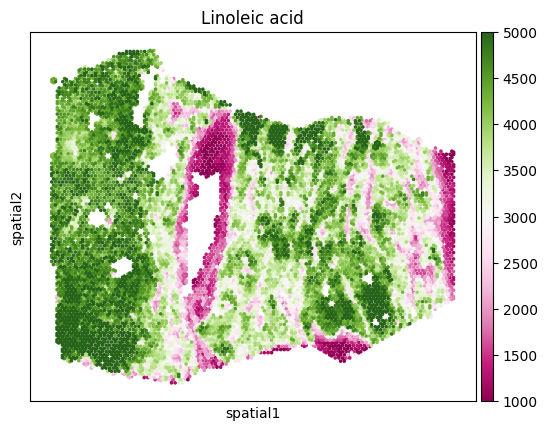

In [114]:
feature = "Linoleic acid"
adata_metabo_enhanced.obs[feature] = adata_metabo_enhanced.obsm["metabolite"][feature]
sc.pl.spatial(adata_metabo_enhanced, color=feature, img_key=None, spot_size=12, alpha=1, cmap="PiYG", vmax=5000, vmin=1000)


/tmp/ipykernel_103658/1210825090.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_metabo_enhanced, color="APOH", img_key=None, spot_size=12, alpha=1, cmap="coolwarm", vmax=7, vmin=4.5)


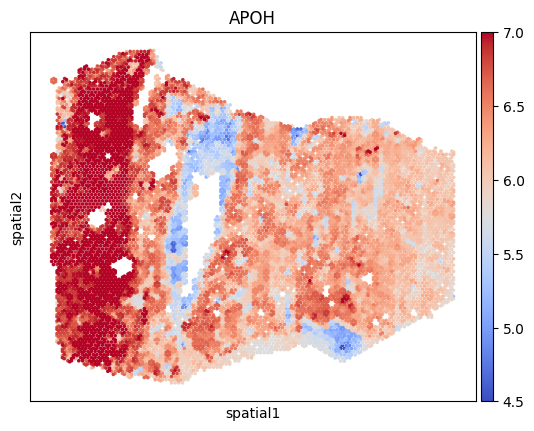

In [125]:
sc.pl.spatial(adata_metabo_enhanced, color="APOH", img_key=None, spot_size=12, alpha=1, cmap="coolwarm", vmax=7, vmin=4.5)


/tmp/ipykernel_103658/1464877503.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_metabo_enhanced, color="spatial.cluster", img_key=None, spot_size=12)


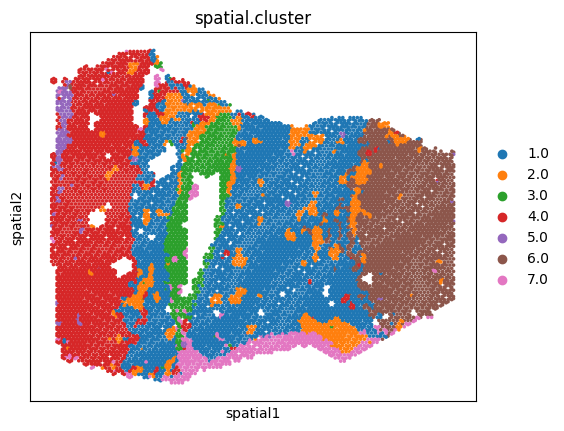

In [136]:
adata_metabo_enhanced.obs["spatial.cluster"] = adata_metabo_enhanced.obs["spatial.cluster"].astype('category')
sc.pl.spatial(adata_metabo_enhanced, color="spatial.cluster", img_key=None, spot_size=12)

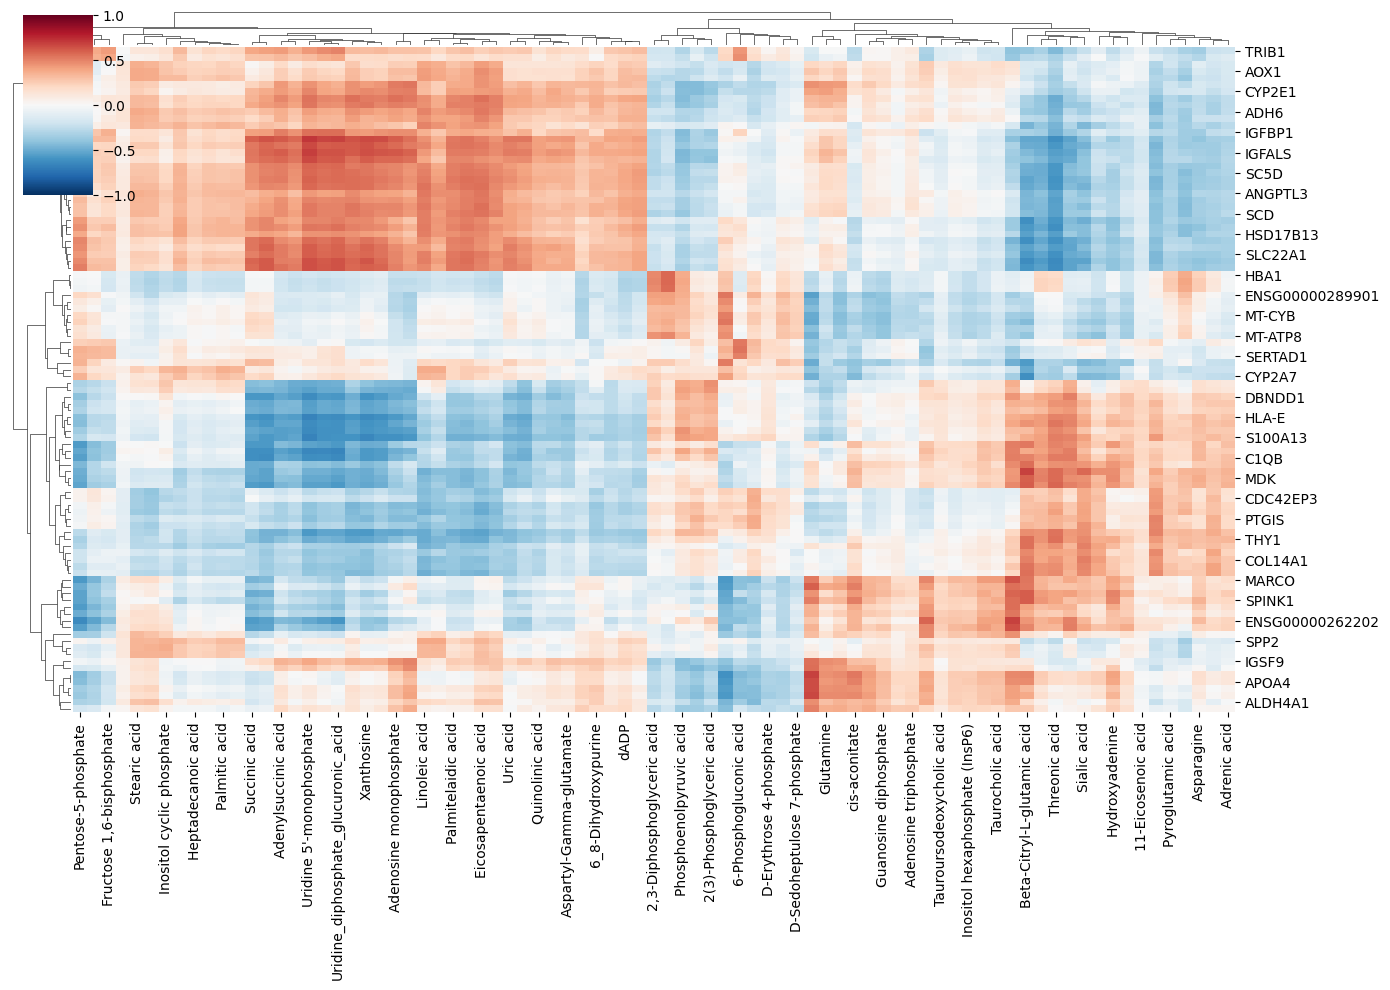

In [ ]:
hvg_mask = adata_metabo_enhanced.var["is.HVG"] == 1
X = adata_metabo_enhanced[:, hvg_mask].X
if hasattr(X, "toarray"):
    X = X.toarray()
X = np.asarray(X, dtype=float)
gene_names = adata_metabo_enhanced.var_names[hvg_mask.values]

metabo_df = adata_metabo_enhanced.obsm["metabolite"]
M = metabo_df.values.astype(float)
metabo_names = metabo_df.columns

valid_mask = np.isfinite(X).all(axis=1) & np.isfinite(M).all(axis=1)
X_valid = X[valid_mask]
M_valid = M[valid_mask]

# vectorized Pearson correlation, every HVG gene vs every metabolite at once
Xz = (X_valid - X_valid.mean(axis=0)) / X_valid.std(axis=0)
Mz = (M_valid - M_valid.mean(axis=0)) / M_valid.std(axis=0)
corr = (Xz.T @ Mz) / X_valid.shape[0]
corr_df = pd.DataFrame(corr, index=gene_names, columns=metabo_names)


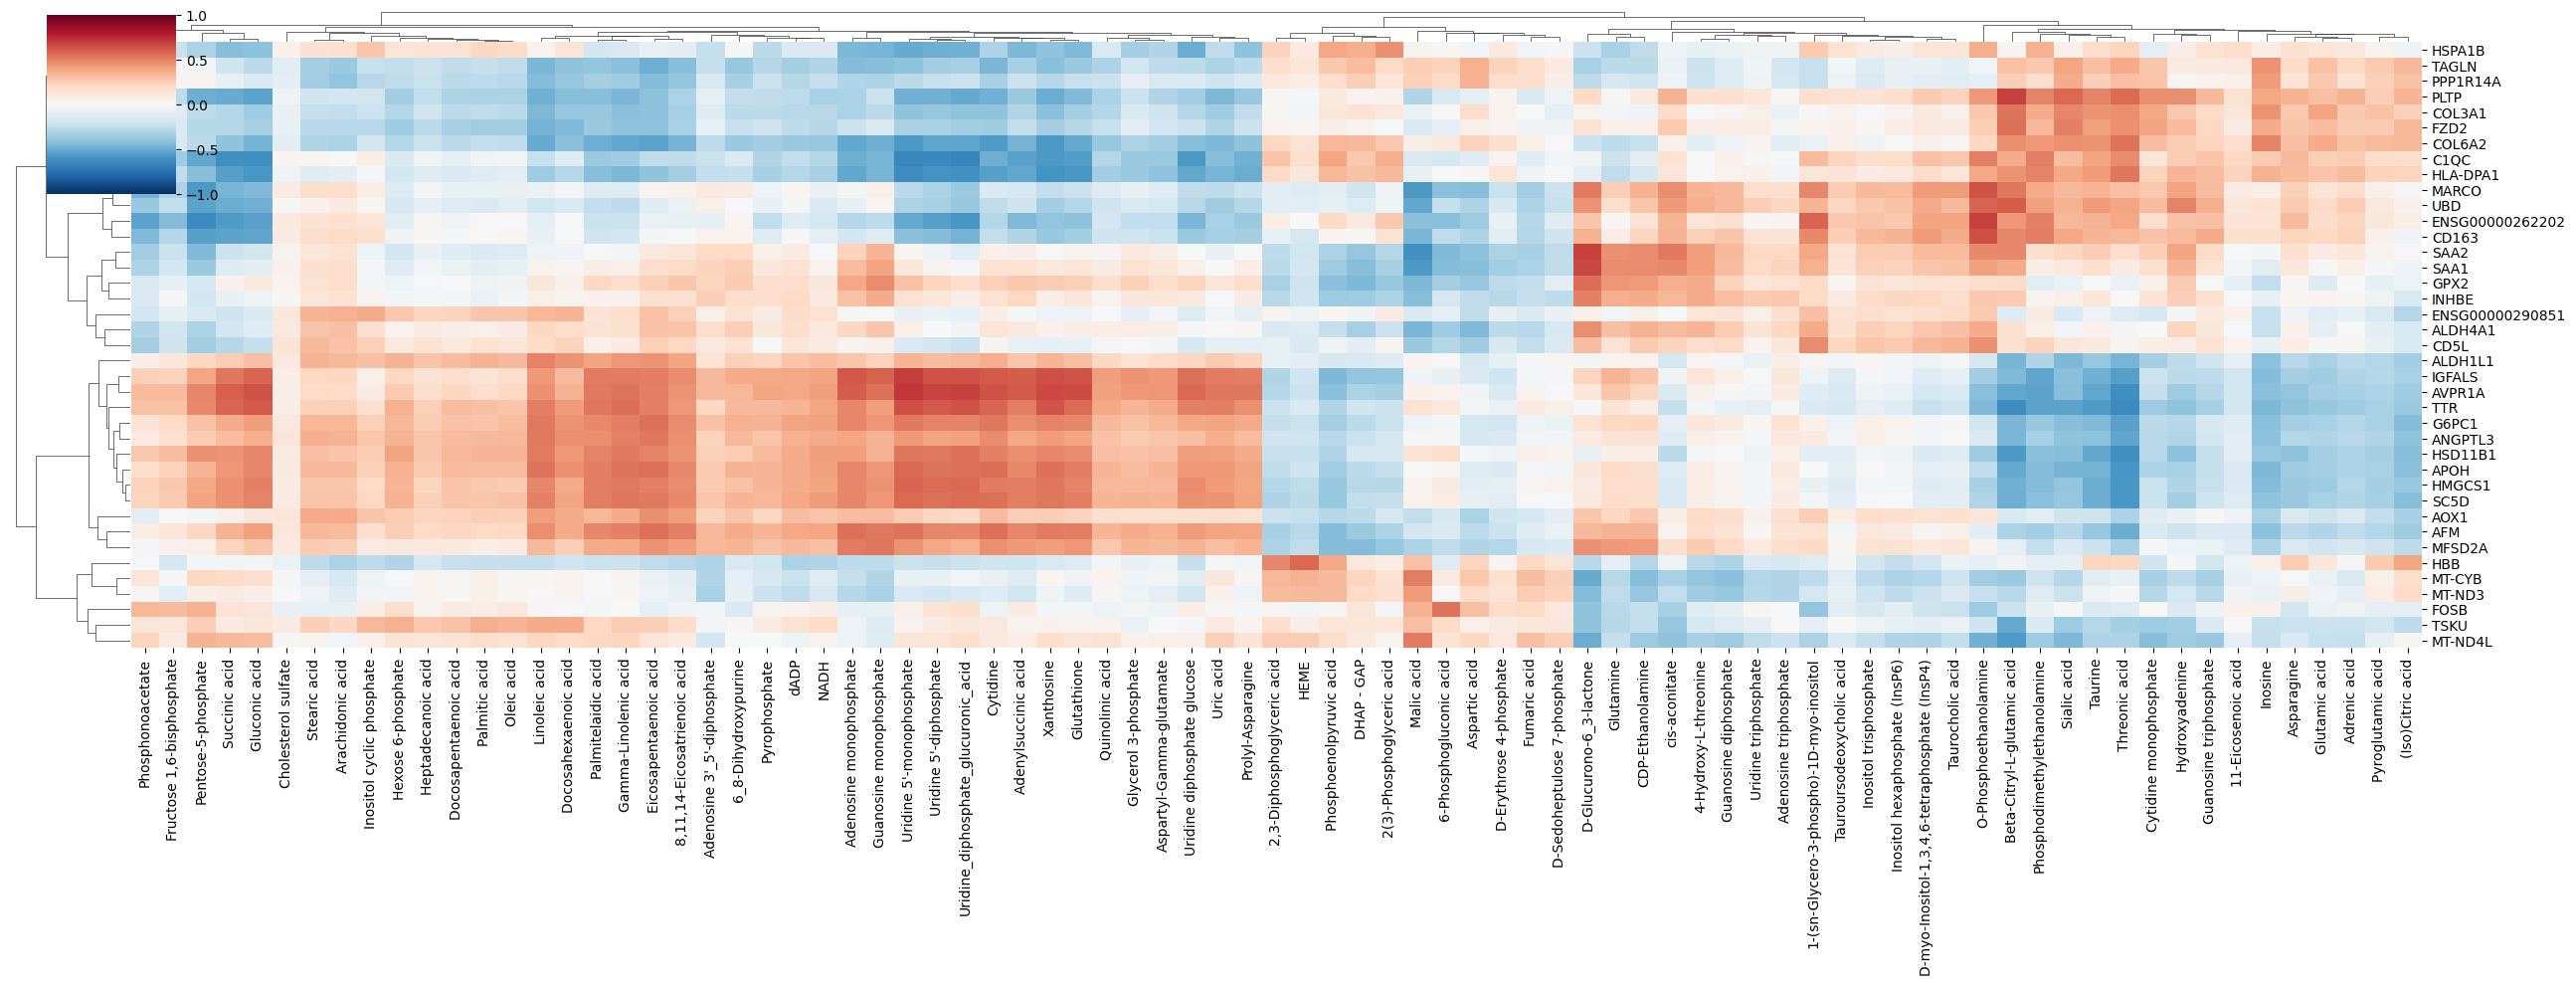

In [145]:

# each metabolite's top-N most correlated genes, union across all metabolites
top_n = 1
top_genes = []
for m in metabo_names:
    top_genes += corr_df[m].abs().sort_values(ascending=False).index[:top_n].tolist()
top_genes = list(dict.fromkeys(top_genes))  # dedupe, keep order

corrplot_df = corr_df.loc[top_genes]

sns.clustermap(corrplot_df, cmap="RdBu_r", vmin=-1, vmax=1, figsize=(26, 10), dendrogram_ratio=(0.05, 0.05))
plt.show()


/tmp/ipykernel_103658/3654939428.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_metabo_enhanced, color=feature, img_key=None, spot_size=12, alpha=1, cmap="PiYG")


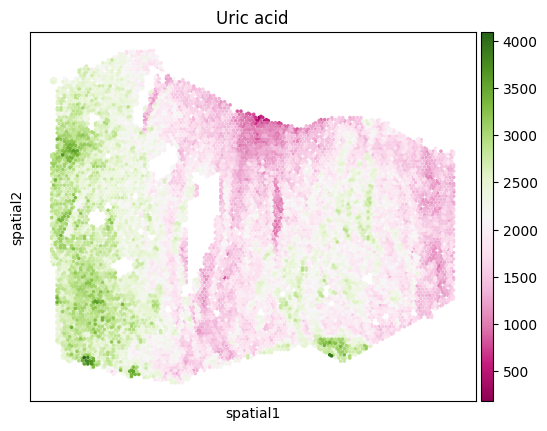

In [166]:
feature =  'Uric acid'
adata_metabo_enhanced.obs[feature] = adata_metabo_enhanced.obsm["metabolite"][feature]
sc.pl.spatial(adata_metabo_enhanced, color=feature, img_key=None, spot_size=12, alpha=1, cmap="PiYG")


/tmp/ipykernel_103658/2572332410.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_metabo_enhanced, color="TTR", img_key=None, spot_size=12, alpha=1, cmap="PiYG", vmin=5)


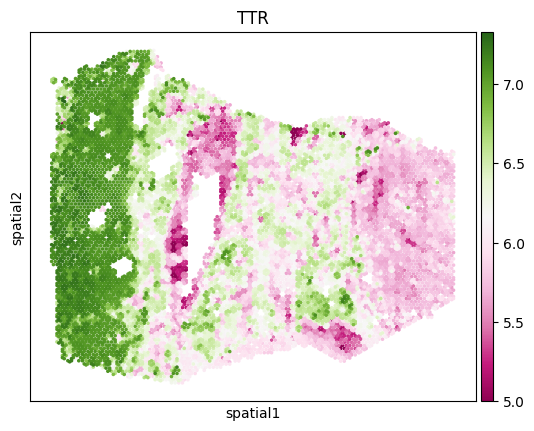

In [170]:
sc.pl.spatial(adata_metabo_enhanced, color="TTR", img_key=None, spot_size=12, alpha=1, cmap="PiYG", vmin=5)


/tmp/ipykernel_103658/2021734576.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_metabo, color="APOH", img_key=None, spot_size=20, alpha=1, cmap="coolwarm", vmax=100)


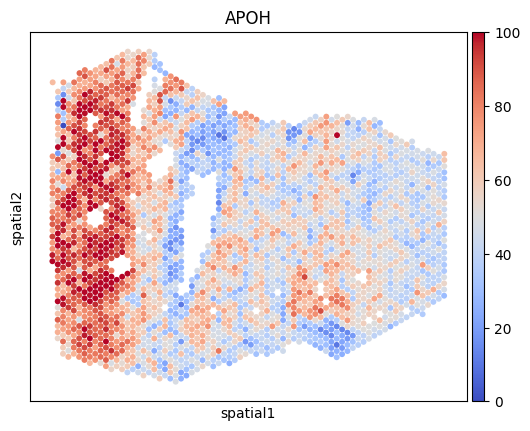

In [132]:
sc.pp.normalize_total(adata_metabo, target_sum=1e4)
sc.pl.spatial(adata_metabo, color="APOH", img_key=None, spot_size=20, alpha=1, cmap="coolwarm", vmax=100)


In [121]:
adata_metabo_enhanced

AnnData object with n_obs × n_vars = 13975 × 38479
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'spot.idx', 'spot.neighbors', 'subspot.idx', 'subspot.neighbors', 'spot.row', 'spot.col', 'array_row', 'array_col', 'spot.pxl.row', 'spot.pxl.col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'spatial.cluster', 'nearest_index', 'nearest_distance', 'Asparagine', 'Linoleic acid'
    var: 'gene_id', 'gene_name', 'is.HVG', 'enhanceFeatures.rmse'
    uns: 'msi_metabolites', 'spatial', 'spatialwarp'
    obsm: 'X_PCA', 'spatial', 'spatial_warped', 'metabolite'

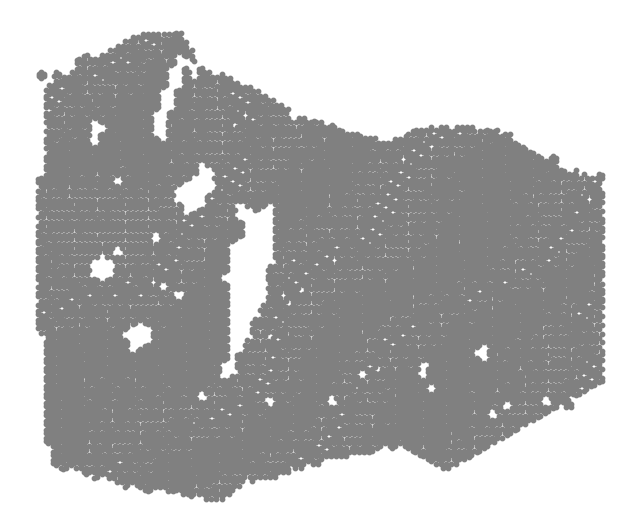

In [118]:
spatial_coords = adata_metabo_enhanced.obsm["spatial"]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(spatial_coords[:, 0], spatial_coords[:, 1], c="grey", s=10)
ax.set_aspect("equal")
ax.invert_yaxis()
ax.axis("off")
plt.show()


In [10]:
adata_metabo.obsm["metabolite"].columns

Index(['Fumaric acid', 'Succinic acid', 'Taurine', 'Pyroglutamic acid',
       'Asparagine', 'Aspartic acid', 'Malic acid', '4-Hydroxy-L-threonine',
       'Threonic acid', 'Phosphonoacetate', 'O-Phosphoethanolamine',
       'Glutamine', 'Glutamic acid', 'Hydroxyadenine', '6_8-Dihydroxypurine',
       'Quinolinic acid', 'Phosphoenolpyruvic acid', 'Uric acid',
       'Phosphodimethylethanolamine', 'DHAP - GAP', 'Glycerol 3-phosphate',
       'cis-aconitate', 'D-Glucurono-6_3-lactone', 'Pyrophosphate',
       '2(3)-Phosphoglyceric acid', '(Iso)Citric acid', 'Gluconic acid',
       'D-Erythrose 4-phosphate', 'Prolyl-Asparagine', 'Pentose-5-phosphate',
       'Inositol cyclic phosphate', 'Cytidine', 'Palmitelaidic acid',
       'Palmitic acid', 'Hexose 6-phosphate', 'Aspartyl-Gamma-glutamate',
       '2,3-Diphosphoglyceric acid', 'Inosine', 'Heptadecanoic acid',
       '6-Phosphogluconic acid', 'Gamma-Linolenic acid', 'Linoleic acid',
       'Oleic acid', 'Xanthosine', 'Stearic acid',
    

In [11]:
channels

NameError: name 'channels' is not defined

In [12]:
%matplotlib inline

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import scanpy as sc
sc.pp.calculate_qc_metrics(adata_metabo, inplace=True, log1p=True)
sc.pp.normalize_total(adata_metabo, target_sum=1e4)


In [15]:
adata_metabo.write_h5ad("/home/croizer/Documents/04_Collaborations/03_Genial/SpatialWarp/adata_metabo_ST.h5ad")

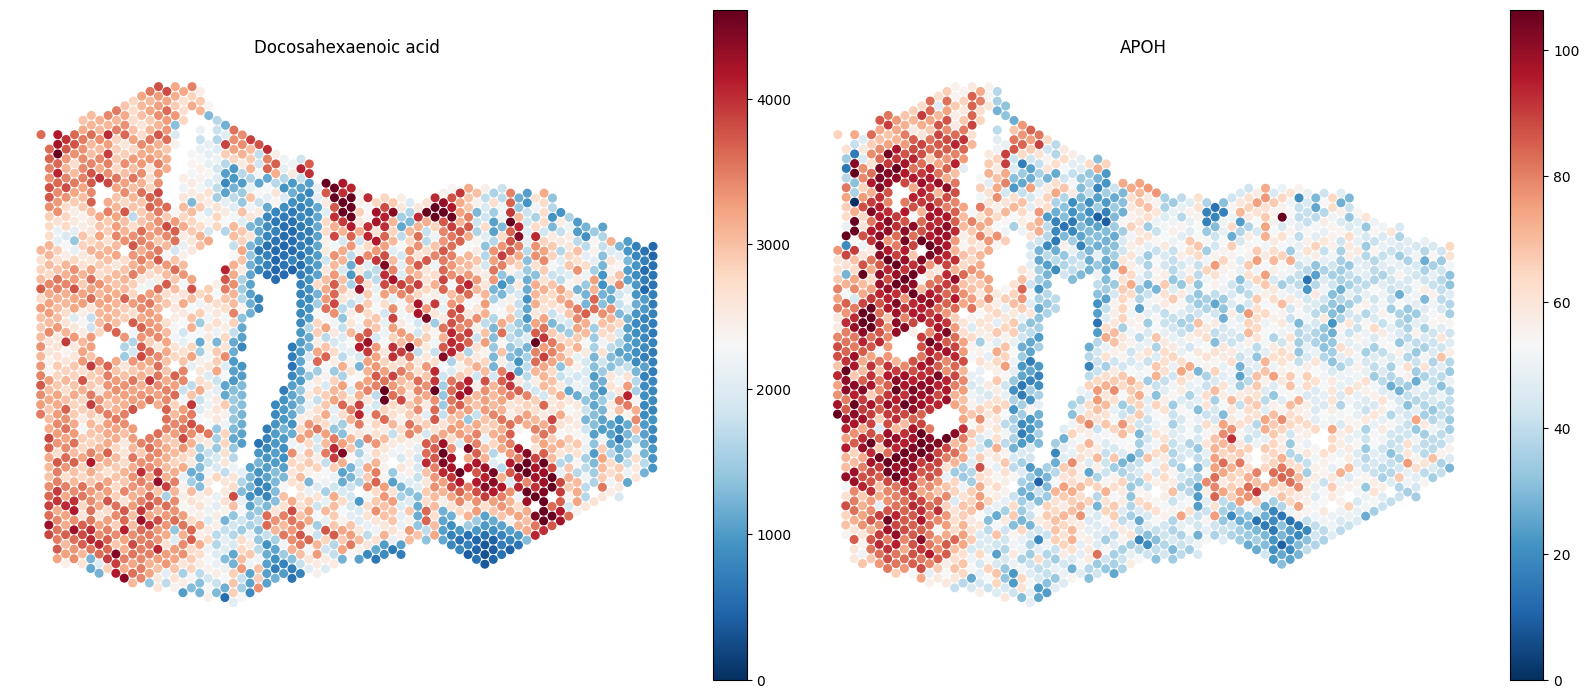

In [14]:
import numpy as np
import matplotlib.pyplot as plt

feature = "Docosahexaenoic acid"
feature_rna = "APOH"

# Get spatial coordinates
spatial_coords = adata_metabo.obsm["spatial"]

# Get metabolite values
metabolite_values = adata_metabo.obsm["metabolite"][feature].values.astype(float)

# Get RNA expression values
rna_values = adata_metabo[:, feature_rna].X

# Convert sparse matrix to array if necessary
if hasattr(rna_values, "toarray"):
    rna_values = rna_values.toarray()

rna_values = np.asarray(rna_values).flatten().astype(float)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# -------------------------
# Metabolite
# -------------------------
vmax_metabo = np.nanpercentile(metabolite_values, 99)

scatter1 = axes[0].scatter(
    spatial_coords[:, 0],
    -spatial_coords[:, 1],
    c=metabolite_values,
    cmap="RdBu_r",
    vmin=0,
    vmax=vmax_metabo,
    s=30
)

axes[0].set_title(feature)
axes[0].set_aspect("equal")
axes[0].axis("off")

plt.colorbar(
    scatter1,
    ax=axes[0],
    fraction=0.046,
    pad=0.04
)

# -------------------------
# RNA
# -------------------------
vmax_rna = np.nanpercentile(rna_values, 99)

scatter2 = axes[1].scatter(
    spatial_coords[:, 0],
    -spatial_coords[:, 1],
    c=rna_values,
    cmap="RdBu_r",
    vmin=0,
    vmax=vmax_rna,
    s=30
)

axes[1].set_title(feature_rna)
axes[1].set_aspect("equal")
axes[1].axis("off")

plt.colorbar(
    scatter2,
    ax=axes[1],
    fraction=0.046,
    pad=0.04
)

plt.tight_layout()
plt.show()

In [21]:
sorted(adata_metabo.obsm["metabolite"].columns)

['(Iso)Citric acid',
 '1-(sn-Glycero-3-phospho)-1D-myo-inositol',
 '11-Eicosenoic acid',
 '2(3)-Phosphoglyceric acid',
 '2,3-Diphosphoglyceric acid',
 '4-Hydroxy-L-threonine',
 '6-Phosphogluconic acid',
 '6_8-Dihydroxypurine',
 '8,11,14-Eicosatrienoic acid',
 "Adenosine 3'_5'-diphosphate",
 'Adenosine monophosphate',
 'Adenosine triphosphate',
 'Adenylsuccinic acid',
 'Adrenic acid',
 'Arachidonic acid',
 'Asparagine',
 'Aspartic acid',
 'Aspartyl-Gamma-glutamate',
 'Beta-Citryl-L-glutamic acid',
 'CDP-Ethanolamine',
 'Cholesterol sulfate',
 'Cytidine',
 'Cytidine monophosphate',
 'D-Erythrose 4-phosphate',
 'D-Glucurono-6_3-lactone',
 'D-Sedoheptulose 7-phosphate',
 'D-myo-Inositol-1,3,4,6-tetraphosphate (InsP4)',
 'DHAP - GAP',
 'Docosahexaenoic acid',
 'Docosapentaenoic acid',
 'Eicosapentaenoic acid',
 'Fructose 1,6-bisphosphate',
 'Fumaric acid',
 'Gamma-Linolenic acid',
 'Gluconic acid',
 'Glutamic acid',
 'Glutamine',
 'Glutathione',
 'Glycerol 3-phosphate',
 'Guanosine diphosph

In [27]:
adata_metabo[:, feature_rna].X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2719 stored elements and shape (2850, 1)>

/tmp/ipykernel_103658/2128540696.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(layer['cmap'])(norm(vals))


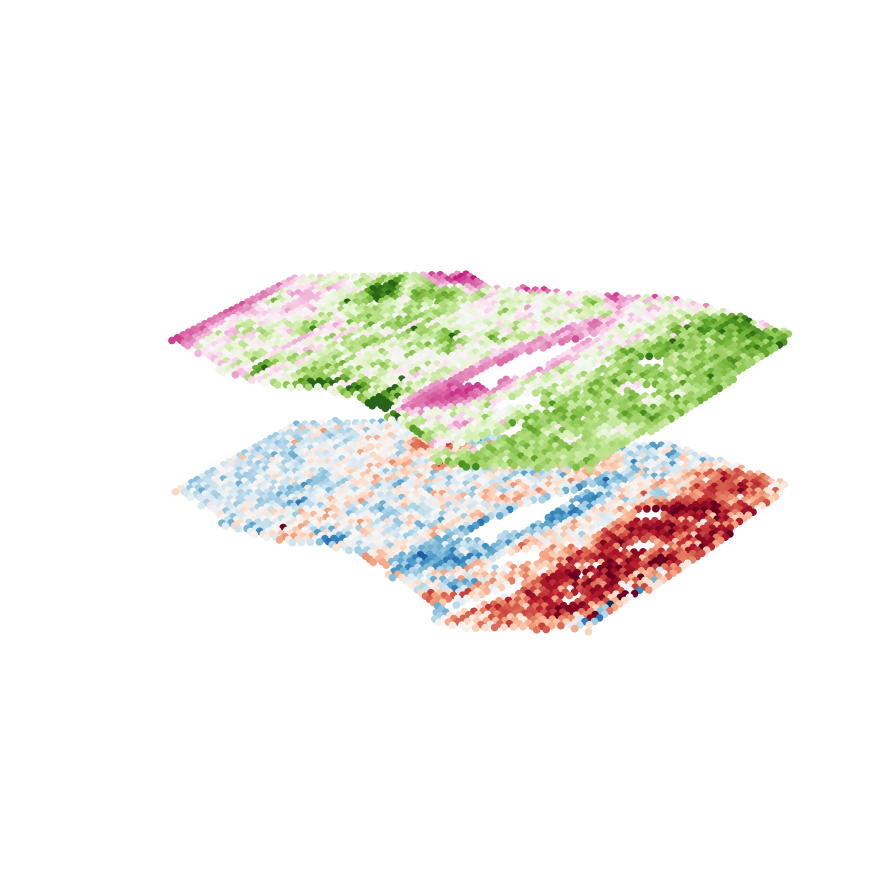

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import Normalize

feature = "Linoleic acid"
feature_rna = "APOH"

# Spatial coordinates
spatial_coords = adata_metabo.obsm["spatial"]
x, y = -spatial_coords[:, 0], spatial_coords[:, 1]

# Metabolite values
metabolite_values = adata_metabo.obsm["metabolite"][feature].values.astype(float)

# RNA values
rna_values = adata_metabo[:, feature_rna].X
if hasattr(rna_values, "toarray"):
    rna_values = rna_values.toarray()
rna_values = np.asarray(rna_values).flatten().astype(float)

# Define layers: RNA at bottom (z=0), metabolite above (z=1)
layers = [
    {
        'name': feature_rna,
        'values': rna_values,
        'cmap': 'RdBu_r',
        'vmin': 0,
        'vmax': np.nanpercentile(rna_values, 99),
        'z': 0
    },
    {
        'name': feature,
        'values': metabolite_values,
        'cmap': 'PiYG',
        'vmin': 0,
        'vmax': np.nanpercentile(metabolite_values, 99),
        'z': 1
    },
]

fig = plt.figure(figsize=(9, 10))
ax = fig.add_subplot(111, projection='3d')

for layer in layers:
    vals = layer['values']
    norm = Normalize(vmin=layer['vmin'], vmax=layer['vmax'])
    colors = cm.get_cmap(layer['cmap'])(norm(vals))

    z = np.full_like(x, layer['z'], dtype=float)

    ax.scatter(
        x, y, z,
        c=colors,
        s=20,
        depthshade=False,
        rasterized=True
    )

ax.set_box_aspect([1, 1, 0.3])
ax.set_axis_off()
ax.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()

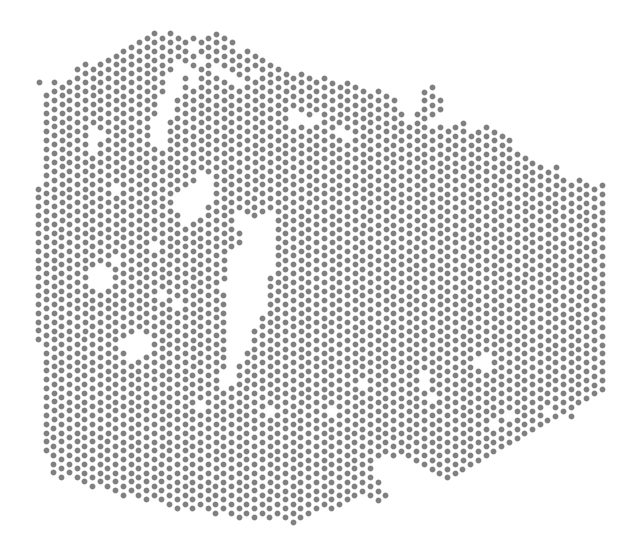

In [53]:
visium_table = visium_sdata.tables["visium"]
spatial_coords = visium_table.obsm["spatial"]

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.scatter(spatial_coords[:, 0], spatial_coords[:, 1], c="grey", s=10)
ax.set_aspect("equal")
ax.invert_yaxis()
ax.axis("off")
plt.show()


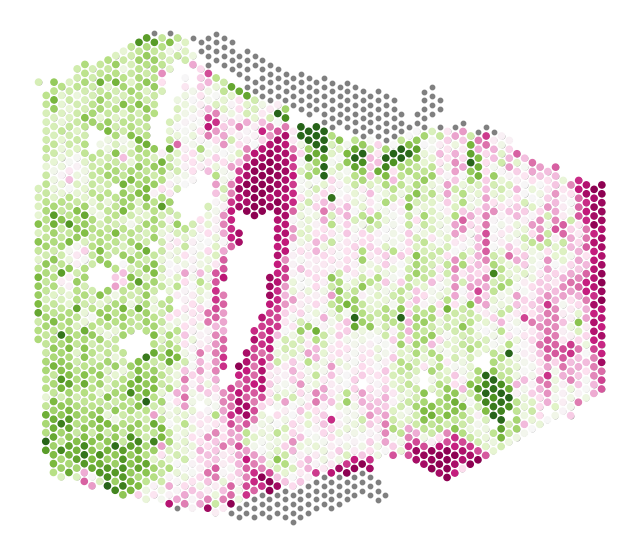

In [57]:
feature = "Linoleic acid"

visium_table = visium_sdata.tables["visium"]
all_spatial = visium_table.obsm["spatial"]

matched_spatial = adata_metabo.obsm["spatial"]
values = adata_metabo.obsm["metabolite"][feature].values.astype(float)
vmin, vmax = np.nanpercentile(values, [1, 99])

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.scatter(all_spatial[:, 0], all_spatial[:, 1], c="grey", s=10)
ax.scatter(matched_spatial[:, 0], matched_spatial[:, 1], c=values, cmap="PiYG", vmin=vmin, vmax=vmax, s=20)
ax.set_aspect("equal")
ax.invert_yaxis()
ax.axis("off")
plt.show()


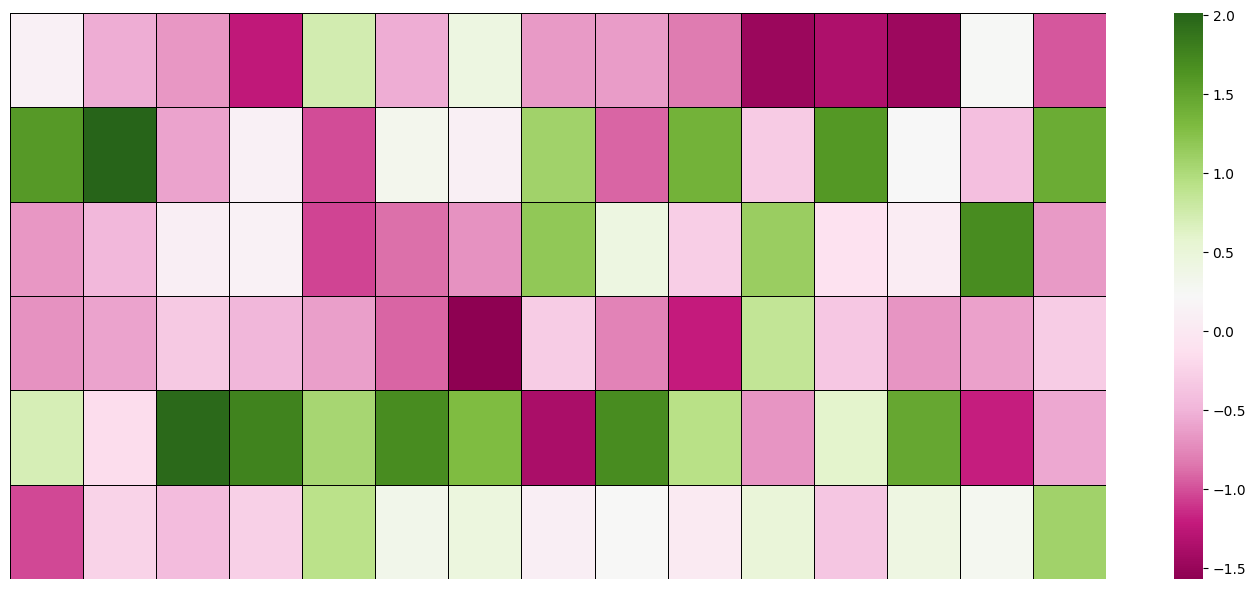

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

metabo_df = adata_metabo.obsm['metabolite']

# take the head (first N rows), all or a subset of columns
head_df = metabo_df.head(6)  # adjust number of rows
head_df = head_df.iloc[:, 0:15]
head_df_z = (head_df - head_df.mean()) / head_df.std()

plt.figure(figsize=(14, 6))
sns.heatmap(
    head_df_z,
    cmap='PiYG',
    cbar=True,
    linewidths=0.5,       # border between cells
    linecolor='black',    # border color
    xticklabels=False,    # no column labels
    yticklabels=False     # no row labels
)
plt.xlabel("")
plt.ylabel("")
plt.title("")
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

feature = "Docosahexaenoic acid"

# Metabolite values (same as before)
metabolite_values = adata_metabo.obsm["metabolite"][feature].values.astype(float)

# Get expression matrix for all genes
X = adata_metabo.X
if hasattr(X, "toarray"):
    X = X.toarray()
X = np.asarray(X, dtype=float)

gene_names = adata_metabo.var_names

# Mask out NaNs in metabolite values
valid_mask = ~np.isnan(metabolite_values)
metabo_valid = metabolite_values[valid_mask]
X_valid = X[valid_mask, :]

# Compute Pearson correlation for every gene (vectorized)
def vectorized_pearson(X, y):
    X_centered = X - X.mean(axis=0)
    y_centered = y - y.mean()
    numerator = X_centered.T @ y_centered
    denominator = np.sqrt((X_centered**2).sum(axis=0) * (y_centered**2).sum())
    denominator[denominator == 0] = np.nan  # avoid div by zero for constant genes
    return numerator / denominator

corrs = vectorized_pearson(X_valid, metabo_valid)

# Build results dataframe
results = pd.DataFrame({
    "gene": gene_names,
    "pearson_r": corrs
})
results["abs_r"] = results["pearson_r"].abs()
results = results.sort_values("abs_r", ascending=False).dropna()

print("Top 20 genes correlated with", feature)
print(results.head(20)[["gene", "pearson_r"]])

NameError: name 'adata_metabo' is not defined

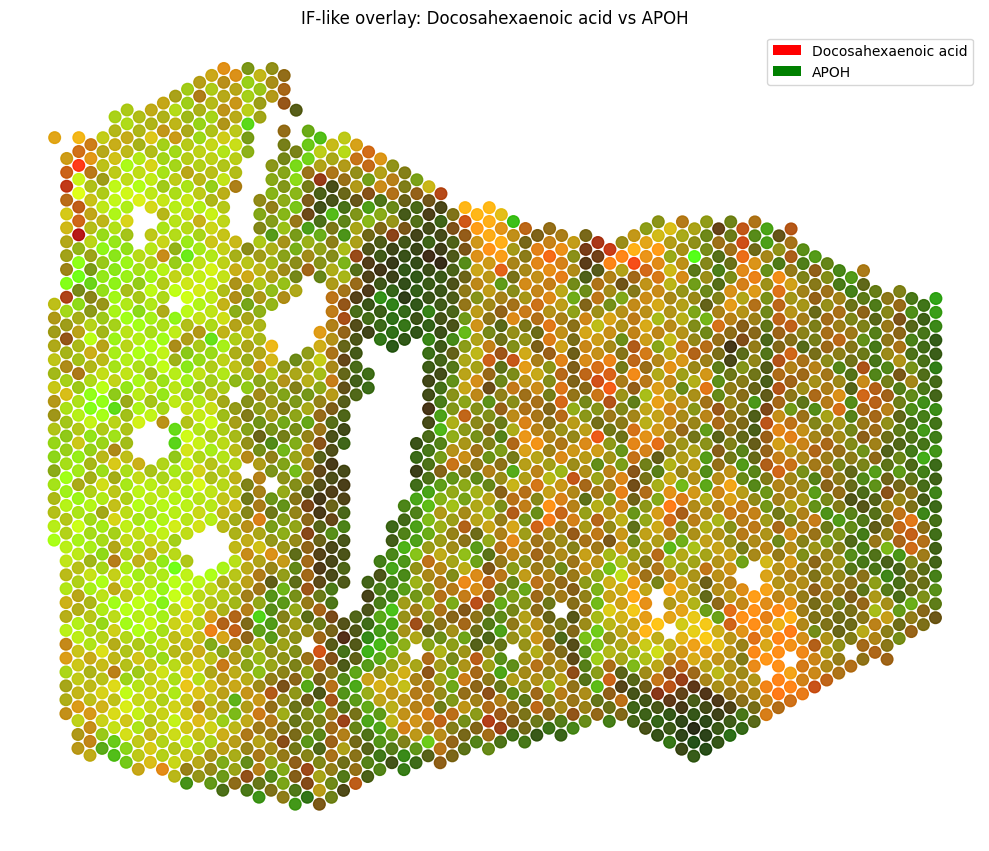

In [ ]:
# map each channel to an RGB color; metabolite columns live in obsm["metabolite"],
# while total_counts (from sc.pp.calculate_qc_metrics) stays in .obs
feature =  "Docosahexaenoic acid"
feature_rna = "APOH"
channels = {
    feature: ("red", adata_metabo.obsm["metabolite"][feature].values),
    feature_rna: ("green", adata_metabo[:, feature_rna].X.toarray().flatten()),
}
color_idx = {"red": 0, "green": 1, "blue": 2}

spatial_coords = adata_metabo.obsm["spatial"]
rgb_image = np.zeros((adata_metabo.n_obs, 3))

for label, (color, values) in channels.items():
    values = values.astype(float)
    vmax = np.nanpercentile(values, 99)
    normalized = np.clip(values / vmax, 0, 1) if vmax > 0 else values
    rgb_image[:, color_idx[color]] = normalized

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(spatial_coords[:, 0], -spatial_coords[:, 1], c=rgb_image, s=70, alpha=0.9)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("IF-like overlay: " + " vs ".join(channels.keys()))

legend_elements = [Patch(facecolor=color, label=label) for label, (color, _) in channels.items()]
ax.legend(handles=legend_elements, loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

leiden
4    802
2    652
3    492
6    353
0    249
5    185
1    117
Name: count, dtype: int64


/home/croizer/miniconda3/envs/msi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/croizer/miniconda3/envs/msi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/croizer/miniconda3/envs/msi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/croizer/miniconda3/envs/msi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/croizer/miniconda3/envs/msi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/

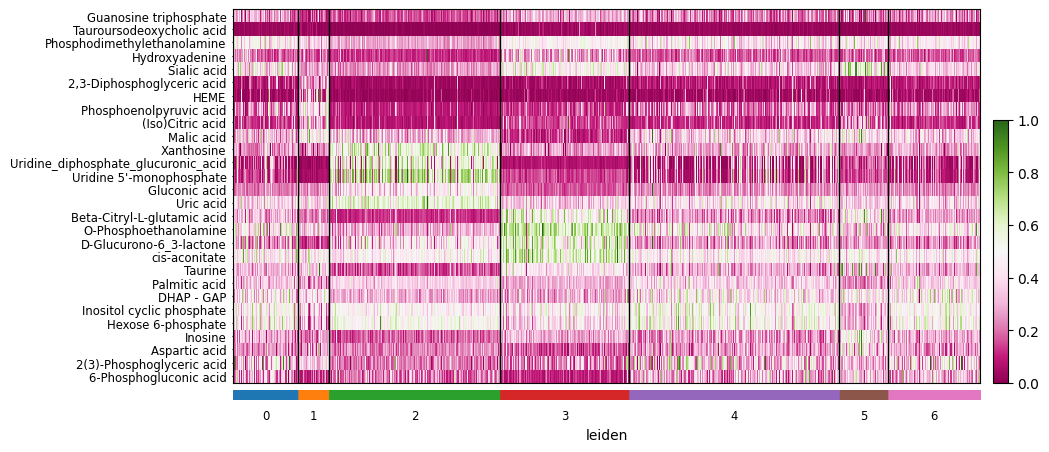

In [73]:
import anndata as ad
import pandas as pd
# --- RNA-based clustering at resolution=0.1 ---
adata_rna = adata_metabo.copy()
sc.pp.normalize_total(adata_rna, target_sum=1e4)
sc.pp.log1p(adata_rna)
sc.pp.highly_variable_genes(adata_rna, n_top_genes=2000)
adata_rna = adata_rna[:, adata_rna.var["highly_variable"]].copy()
sc.pp.scale(adata_rna, max_value=10)
sc.tl.pca(adata_rna)
sc.pp.neighbors(adata_rna)
sc.tl.leiden(adata_rna, resolution=0.5, flavor="igraph", n_iterations=2, directed=False)

adata_metabo.obs["leiden"] = adata_rna.obs["leiden"].values
print(adata_metabo.obs["leiden"].value_counts())

# --- differential metabolites per cluster ---
metabo_adata = ad.AnnData(
    X=adata_metabo.obsm["metabolite"].values,
    obs=adata_metabo.obs[["leiden"]].copy(),
    var=pd.DataFrame(index=adata_metabo.obsm["metabolite"].columns),
)
sc.tl.rank_genes_groups(metabo_adata, groupby="leiden", method="wilcoxon")

top_n = 5
top_metabolites = []
for cluster in metabo_adata.obs["leiden"].cat.categories:
    top_metabolites += list(metabo_adata.uns["rank_genes_groups"]["names"][cluster][:top_n])
top_metabolites = list(dict.fromkeys(top_metabolites))  # dedupe, keep rank order

sc.pl.heatmap(
    metabo_adata,
    var_names=top_metabolites,
    groupby="leiden",
    cmap="PiYG",
    standard_scale="var",
    swap_axes=True, )


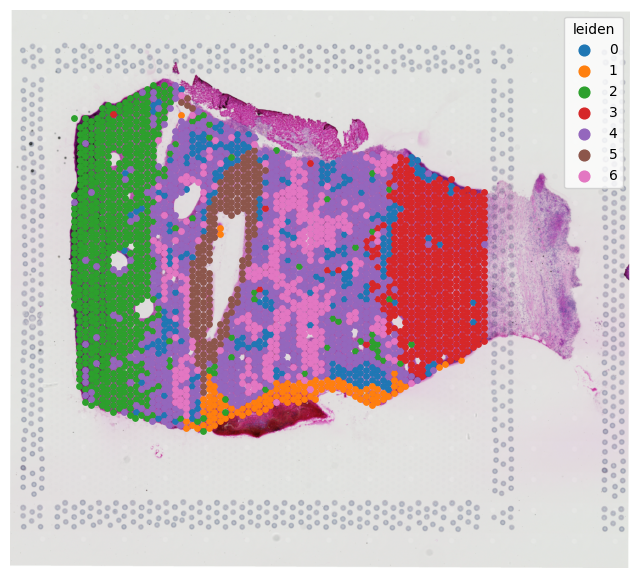

In [74]:
spatial_coords = adata_metabo.obsm["spatial"]
clusters = adata_metabo.obs["leiden"]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(visium_hires_array)

for cluster in clusters.cat.categories:
    mask = clusters == cluster
    ax.scatter(spatial_coords[mask, 0], spatial_coords[mask, 1], s=15, label=cluster)

ax.set_aspect("equal")
ax.axis("off")
ax.legend(title="leiden", markerscale=2, loc="upper right", frameon=True)
plt.show()


/tmp/ipykernel_103658/2507671475.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = metabo_df.groupby("leiden").mean()


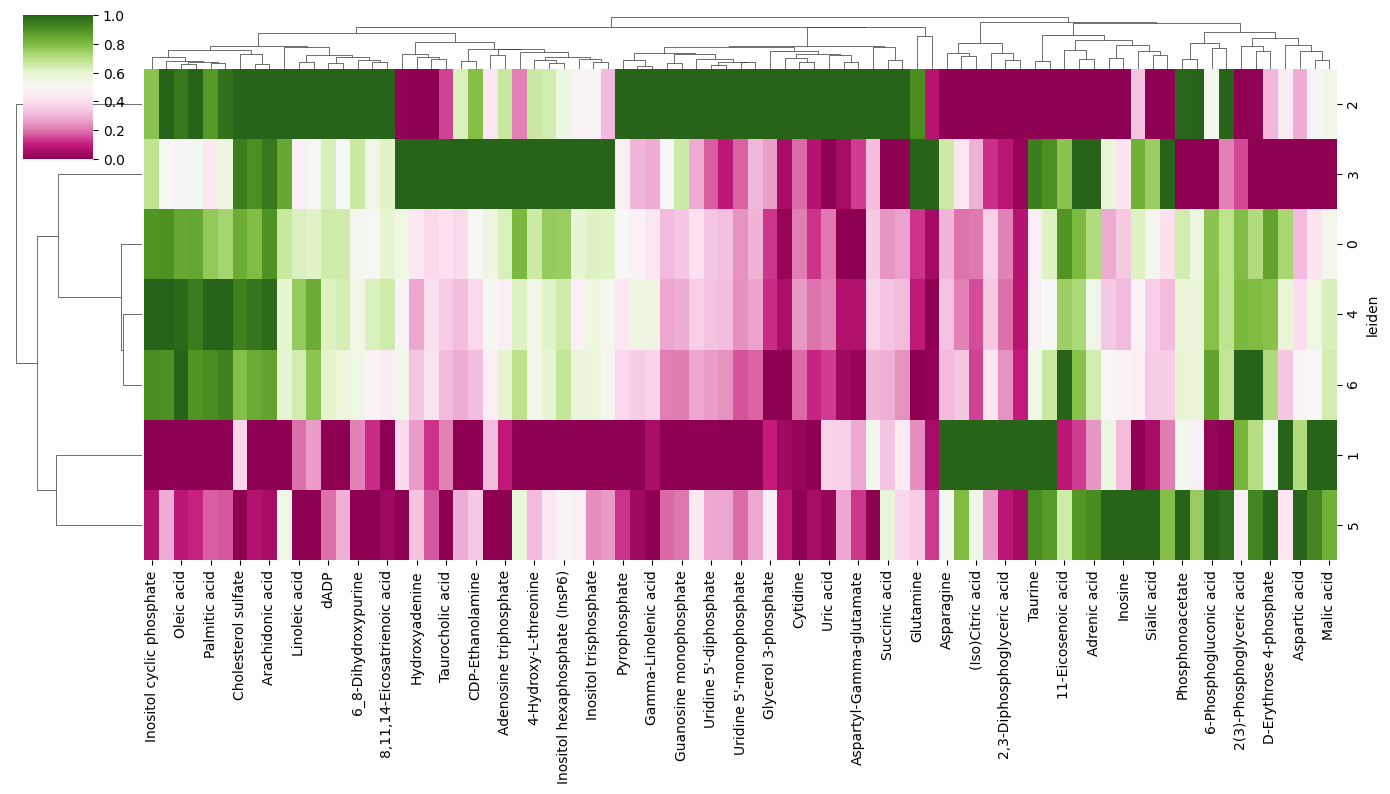

In [81]:
import seaborn as sns

metabo_df = adata_metabo.obsm["metabolite"].copy()
metabo_df["leiden"] = adata_metabo.obs["leiden"].values
cluster_means = metabo_df.groupby("leiden").mean()

sns.clustermap(
    cluster_means,
    cmap="PiYG",
    standard_scale=1,
    figsize=(14, 8),
    dendrogram_ratio=(0.1, 0.1),
)
plt.show()


/tmp/ipykernel_103658/3098554249.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means_genes = gene_df.groupby("leiden").mean()


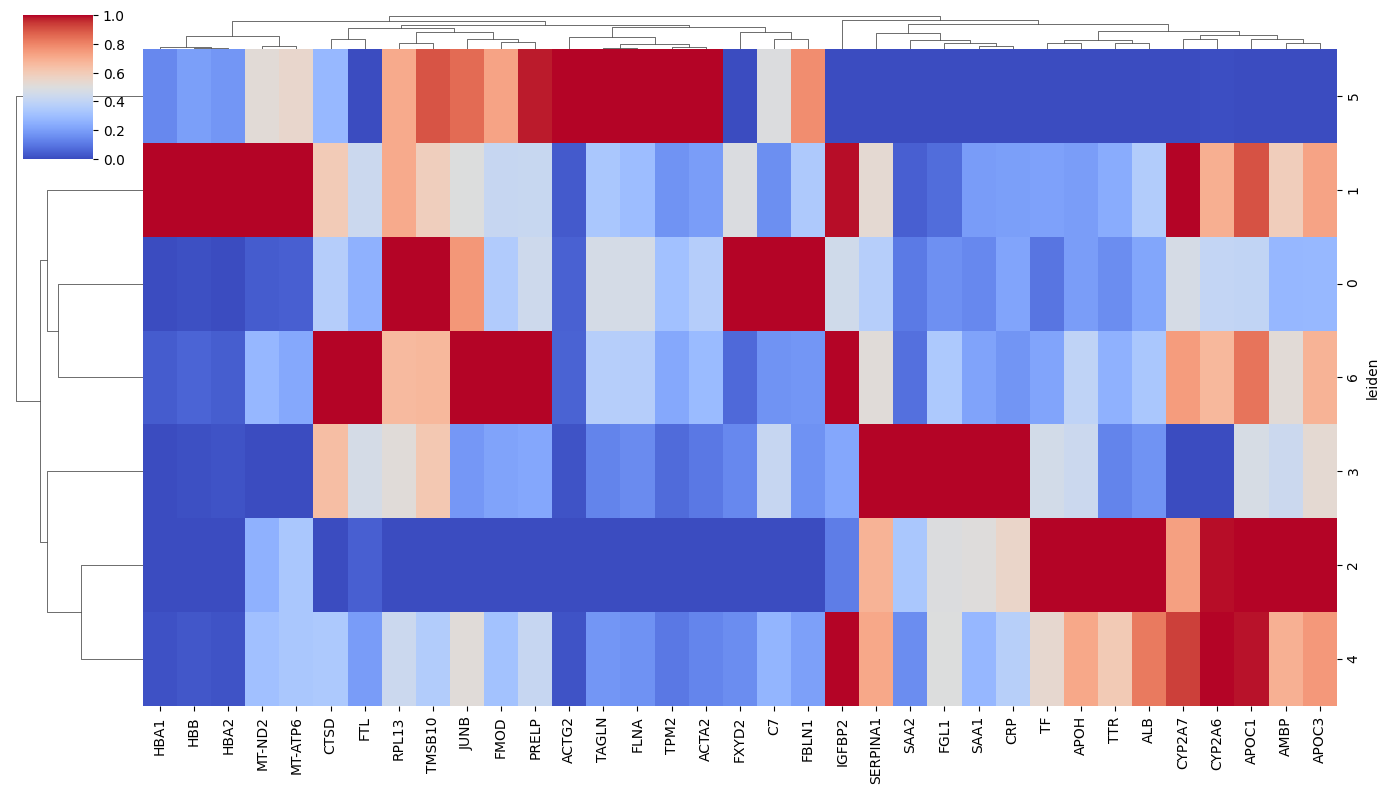

In [78]:
adata_rna_full = adata_metabo.copy()
sc.pp.normalize_total(adata_rna_full, target_sum=1e4)
sc.pp.log1p(adata_rna_full)
adata_rna_full.obs["leiden"] = adata_metabo.obs["leiden"].values

sc.tl.rank_genes_groups(adata_rna_full, groupby="leiden", method="wilcoxon")

top_n = 5
top_genes = []
for cluster in adata_rna_full.obs["leiden"].cat.categories:
    top_genes += list(adata_rna_full.uns["rank_genes_groups"]["names"][cluster][:top_n])
top_genes = list(dict.fromkeys(top_genes))  # dedupe, keep rank order

X_top = adata_rna_full[:, top_genes].X
if hasattr(X_top, "toarray"):
    X_top = X_top.toarray()
gene_df = pd.DataFrame(X_top, columns=top_genes, index=adata_rna_full.obs_names)
gene_df["leiden"] = adata_rna_full.obs["leiden"].values
cluster_means_genes = gene_df.groupby("leiden").mean()

sns.clustermap(
    cluster_means_genes,
    cmap="coolwarm",
    standard_scale=1,
    figsize=(14, 8),
    dendrogram_ratio=(0.1, 0.1),
)

plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

feature = "Adrenic acid"

# Metabolite values (same as before)
metabolite_values = adata_metabo.obsm["metabolite"][feature].values.astype(float)

# Get expression matrix for all genes
X = adata_metabo.X
if hasattr(X, "toarray"):
    X = X.toarray()
X = np.asarray(X, dtype=float)

gene_names = adata_metabo.var_names

# Mask out NaNs in metabolite values
valid_mask = ~np.isnan(metabolite_values)
metabo_valid = metabolite_values[valid_mask]
X_valid = X[valid_mask, :]

# Compute Pearson correlation for every gene (vectorized)
def vectorized_pearson(X, y):
    X_centered = X - X.mean(axis=0)
    y_centered = y - y.mean()
    numerator = X_centered.T @ y_centered
    denominator = np.sqrt((X_centered**2).sum(axis=0) * (y_centered**2).sum())
    denominator[denominator == 0] = np.nan  # avoid div by zero for constant genes
    return numerator / denominator

corrs = vectorized_pearson(X_valid, metabo_valid)

# Build results dataframe
results = pd.DataFrame({
    "gene": gene_names,
    "pearson_r": corrs
})
results["abs_r"] = results["pearson_r"].abs()
results = results.sort_values("abs_r", ascending=False).dropna()

print("Top 20 genes correlated with", feature)
print(results.head(20)[["gene", "pearson_r"]])

Top 20 genes correlated with Adrenic acid
            gene  pearson_r
32031        TTR  -0.341091
17998       AMBP  -0.333841
31259       APOH  -0.308434
8910         ALB  -0.303677
4535      TMSB10   0.296216
7557          TF  -0.288050
21805      APOC3  -0.282529
29573      RPL13   0.266693
17885      ALDOB  -0.266592
8081        AHSG  -0.265819
33943      APOC1  -0.262706
9575         FGB  -0.254284
37210     TMSB4X   0.248540
2452       APOA2  -0.246435
2629    SERPINC1  -0.245366
19444       RBP4  -0.242332
10073  BASP1-AS1   0.233964
21775       NNMT  -0.233518
32716       LRG1  -0.230545
12383    HLA-DRA   0.228139


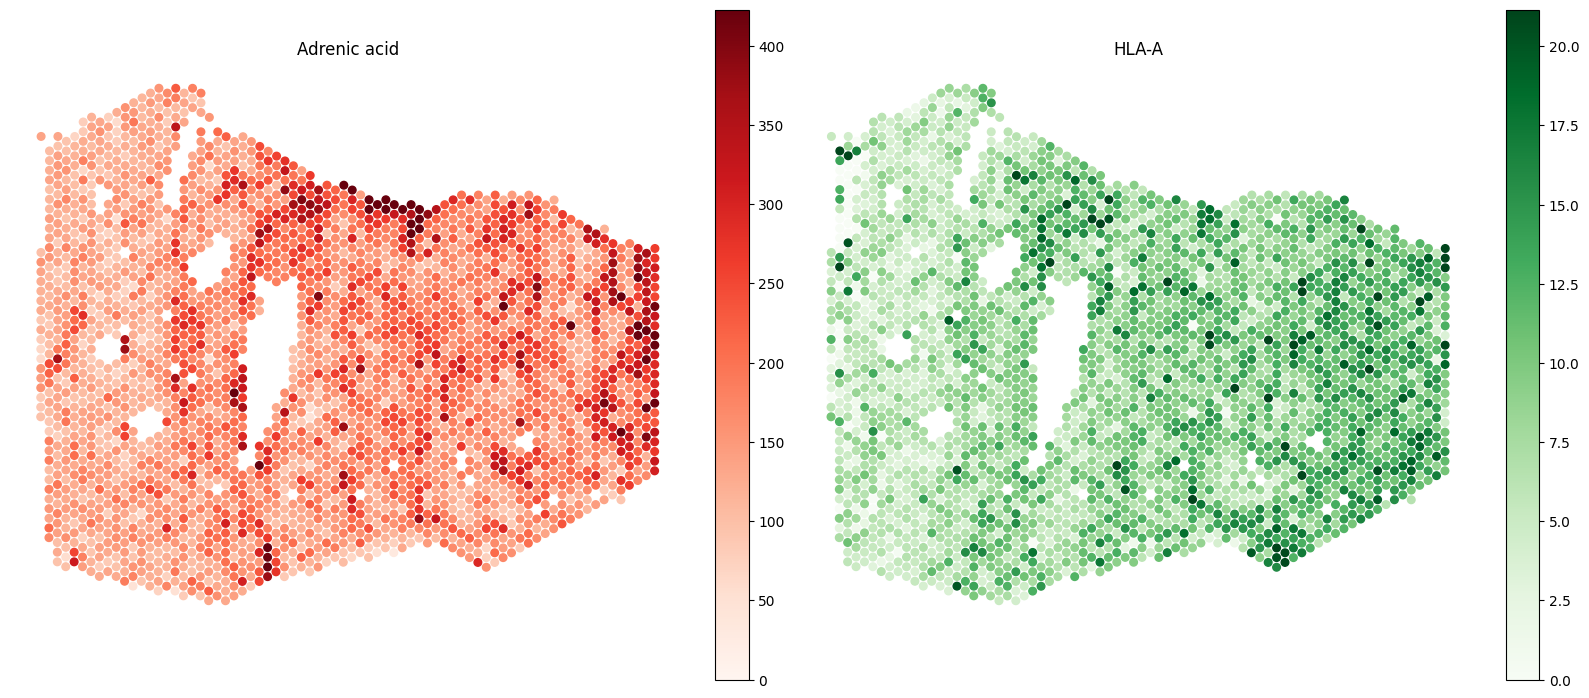

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

feature = "Adrenic acid"
feature_rna = "HLA-A"

# Get spatial coordinates
spatial_coords = adata_metabo.obsm["spatial"]

# Get metabolite values
metabolite_values = adata_metabo.obsm["metabolite"][feature].values.astype(float)

# Get RNA expression values
rna_values = adata_metabo[:, feature_rna].X

# Convert sparse matrix to array if necessary
if hasattr(rna_values, "toarray"):
    rna_values = rna_values.toarray()

rna_values = np.asarray(rna_values).flatten().astype(float)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# -------------------------
# Metabolite
# -------------------------
vmax_metabo = np.nanpercentile(metabolite_values, 99)

scatter1 = axes[0].scatter(
    spatial_coords[:, 0],
    -spatial_coords[:, 1],
    c=metabolite_values,
    cmap="Reds",
    vmin=0,
    vmax=vmax_metabo,
    s=30
)

axes[0].set_title(feature)
axes[0].set_aspect("equal")
axes[0].axis("off")

plt.colorbar(
    scatter1,
    ax=axes[0],
    fraction=0.046,
    pad=0.04
)

# -------------------------
# RNA
# -------------------------
vmax_rna = np.nanpercentile(rna_values, 99)

scatter2 = axes[1].scatter(
    spatial_coords[:, 0],
    -spatial_coords[:, 1],
    c=rna_values,
    cmap="Greens",
    vmin=0,
    vmax=vmax_rna,
    s=30
)

axes[1].set_title(feature_rna)
axes[1].set_aspect("equal")
axes[1].axis("off")

plt.colorbar(
    scatter2,
    ax=axes[1],
    fraction=0.046,
    pad=0.04
)

plt.tight_layout()
plt.show()

RNA matrix: (2820, 38479)
Metabolite matrix: (2820, 81)
Number of valid spatial locations: 2820
Leiden found 11 transcriptomic clusters

Confusion matrix:
Metabolite cluster (K-means)  0   1    2   3    4   5   6   7   8    9    10  \
RNA cluster (Leiden)                                                           
0                              0   0    1   0  199  41   1   0   1    0  249   
1                             19   9   30   0    5  35  13   4   3    0   15   
2                             19   7   81  44    0  13  10  65   0   65    0   
3                              1   5    1  49    0   0   0   3   0  257    0   
4                              7  10    0  55    2   4   0   2   0  209    0   
5                             17  11  103   3    4  17   4  29   3    1    1   
6                              9   1   46   6    7  27  17  27   0    6   17   
7                              2   4   38   2    0   1  91   0  34    0    0   
8                              3   4   55   0

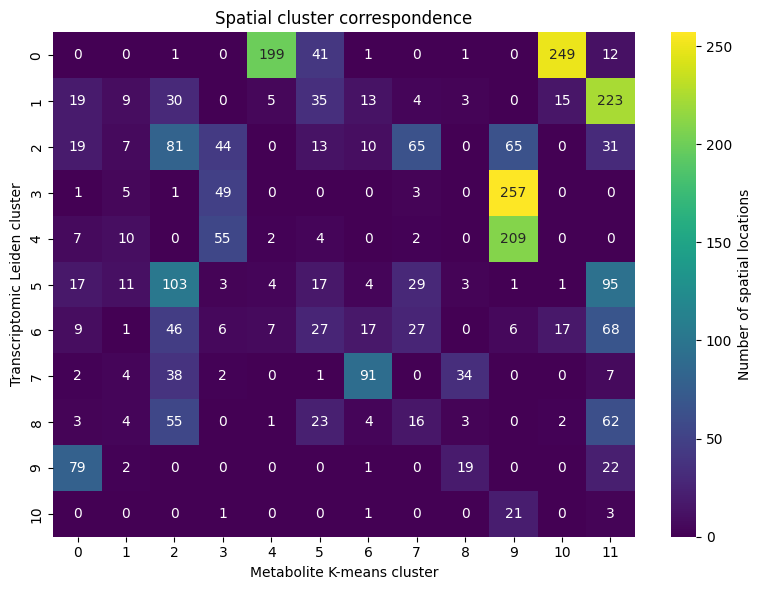

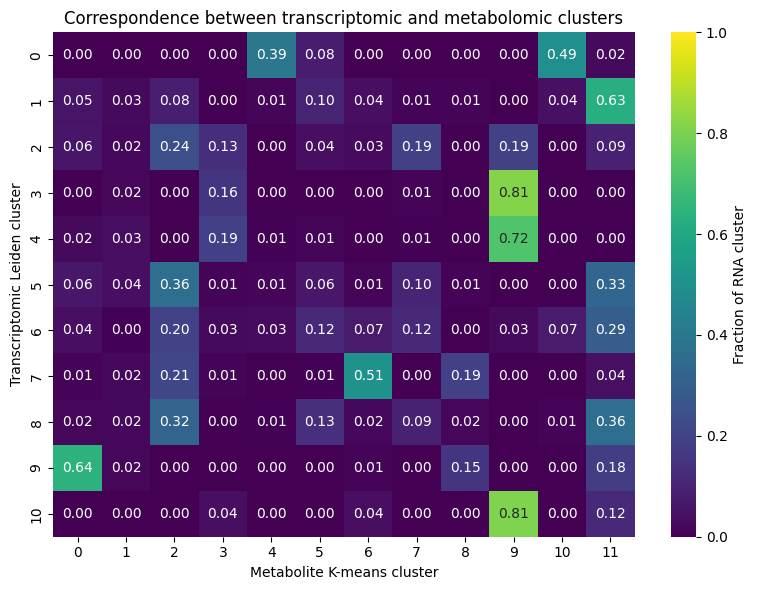

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ============================================================
# Parameters
# ============================================================

n_clusters_metabo = 12
random_state = 42

leiden_resolution = 1.0
n_pcs = 30
n_neighbors = 15

# ============================================================
# 1. Get transcriptomic expression matrix
# ============================================================

X_rna = adata_metabo.X

if hasattr(X_rna, "toarray"):
    X_rna = X_rna.toarray()

X_rna = np.asarray(X_rna, dtype=float)

# ============================================================
# 2. Get metabolomic matrix
# ============================================================

metabo_df = adata_metabo.obsm["metabolite"]
metabolite_names = metabo_df.columns
X_metabo = metabo_df.values.astype(float)

print("RNA matrix:", X_rna.shape)
print("Metabolite matrix:", X_metabo.shape)

# ============================================================
# 3. Keep spatial locations with valid data
# ============================================================

valid_rna = np.isfinite(X_rna).all(axis=1)
valid_metabo = np.isfinite(X_metabo).all(axis=1)

valid_mask = valid_rna & valid_metabo

X_rna_valid = X_rna[valid_mask]
X_metabo_valid = X_metabo[valid_mask]

print("Number of valid spatial locations:", valid_mask.sum())

# ============================================================
# 4. Leiden clustering of transcriptomic data
# ============================================================
# Build a fresh AnnData restricted to valid locations so scanpy's
# standard pipeline (PCA -> neighbors -> leiden) can be used.

adata_rna_valid = sc.AnnData(X=X_rna_valid)
adata_rna_valid.obs_names = adata_metabo.obs_names[valid_mask]

# If X_rna is already processed/scaled data (not raw counts), skip
# normalization/log1p. Uncomment the next two lines if X_rna is raw counts.
# sc.pp.normalize_total(adata_rna_valid, target_sum=1e4)
# sc.pp.log1p(adata_rna_valid)

sc.pp.scale(adata_rna_valid, max_value=10)

sc.tl.pca(adata_rna_valid, n_comps=min(n_pcs, X_rna_valid.shape[1] - 1), random_state=random_state)

sc.pp.neighbors(adata_rna_valid, n_neighbors=n_neighbors, random_state=random_state)

sc.tl.leiden(
    adata_rna_valid,
    resolution=leiden_resolution,
    random_state=random_state,
    key_added="leiden"
)

rna_clusters = adata_rna_valid.obs["leiden"].astype(int).values

n_clusters_rna_found = len(np.unique(rna_clusters))
print(f"Leiden found {n_clusters_rna_found} transcriptomic clusters")

# ============================================================
# 5. Scale metabolomic data
# ============================================================

scaler_metabo = StandardScaler()
X_metabo_scaled = scaler_metabo.fit_transform(X_metabo_valid)

# ============================================================
# 6. K-means clustering of metabolomic data
# ============================================================

kmeans_metabo = KMeans(
    n_clusters=n_clusters_metabo,
    random_state=random_state,
    n_init=20
)

metabo_clusters = kmeans_metabo.fit_predict(X_metabo_scaled)

# ============================================================
# 7. Build confusion / contingency matrix
# ============================================================

confusion = pd.crosstab(
    pd.Series(rna_clusters, name="RNA cluster (Leiden)"),
    pd.Series(metabo_clusters, name="Metabolite cluster (K-means)")
)

print("\nConfusion matrix:")
print(confusion)

# ============================================================
# 8. Plot raw confusion matrix
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="viridis",
    cbar_kws={"label": "Number of spatial locations"}
)

plt.xlabel("Metabolite K-means cluster")
plt.ylabel("Transcriptomic Leiden cluster")
plt.title("Spatial cluster correspondence")

plt.tight_layout()
plt.show()

# ============================================================
# 9. Row-normalized confusion matrix
# ============================================================

confusion_normalized = confusion.div(confusion.sum(axis=1), axis=0)

plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_normalized,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Fraction of RNA cluster"}
)

plt.xlabel("Metabolite K-means cluster")
plt.ylabel("Transcriptomic Leiden cluster")
plt.title("Correspondence between transcriptomic and metabolomic clusters")

plt.tight_layout()
plt.show()

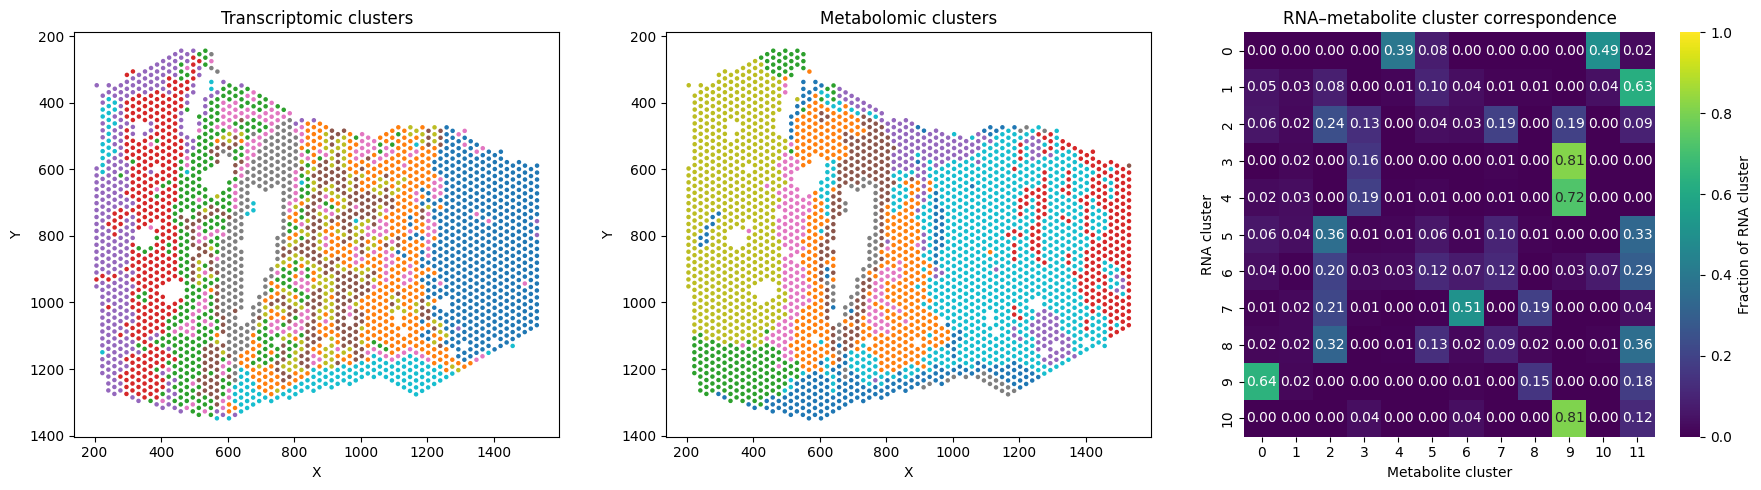

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ============================================================
# Get spatial coordinates
# ============================================================

coords = adata_metabo.obsm["spatial"]

# Keep only locations used for clustering
coords_valid = coords[valid_mask]

# ============================================================
# Create figure
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ============================================================
# 1. Transcriptomic clusters
# ============================================================

axes[0].scatter(
    coords_valid[:, 0],
    coords_valid[:, 1],
    c=rna_clusters,
    s=5,
    cmap="tab10"
)

axes[0].set_title("Transcriptomic clusters")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].invert_yaxis()
axes[0].set_aspect("equal")

# ============================================================
# 2. Metabolomic clusters
# ============================================================

axes[1].scatter(
    coords_valid[:, 0],
    coords_valid[:, 1],
    c=metabo_clusters,
    s=5,
    cmap="tab10"
)

axes[1].set_title("Metabolomic clusters")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].invert_yaxis()
axes[1].set_aspect("equal")

# ============================================================
# 3. Confusion matrix
# ============================================================

confusion_normalized = confusion.div(
    confusion.sum(axis=1),
    axis=0
)

sns.heatmap(
    confusion_normalized,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    ax=axes[2],
    cbar_kws={"label": "Fraction of RNA cluster"}
)

axes[2].set_title("RNA–metabolite cluster correspondence")
axes[2].set_xlabel("Metabolite cluster")
axes[2].set_ylabel("RNA cluster")

plt.tight_layout()
plt.show()

Step 1: shapes
(11, 12) (11, 12)
Step 2: linkage
linkage OK
Step 3: ordering
row_order: [10  3  4  0  9  7  1  2  6  5  8]
col_order: [ 9 11  0  2  6  4 10  8  3  7  1  5]
Step 4: reorder
Metabolite cluster (K-means)   9    11  0    2   6    4    10  8   3   7   1   \
RNA cluster (Leiden)                                                            
10                             21    3   0    0   1    0    0   0   1   0   0   
3                             257    0   1    1   0    0    0   0  49   3   5   
4                             209    0   7    0   0    2    0   0  55   2  10   
0                               0   12   0    1   1  199  249   1   0   0   0   
9                               0   22  79    0   1    0    0  19   0   0   2   
7                               0    7   2   38  91    0    0  34   2   0   4   
1                               0  223  19   30  13    5   15   3   0   4   9   
2                              65   31  19   81  10    0    0   0  44  65   7   
6 

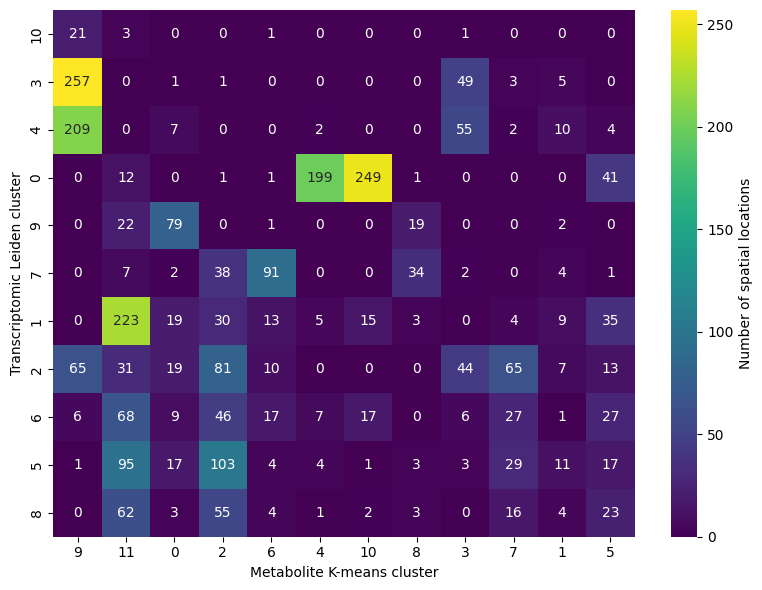

Done


In [ ]:
from scipy.cluster.hierarchy import linkage, leaves_list
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 1: shapes")
print(confusion.shape, confusion_normalized.shape)

print("Step 2: linkage")
row_linkage = linkage(confusion_normalized, method="average")
col_linkage = linkage(confusion_normalized.T, method="average")
print("linkage OK")

print("Step 3: ordering")
row_order = leaves_list(row_linkage)
col_order = leaves_list(col_linkage)
print("row_order:", row_order)
print("col_order:", col_order)

print("Step 4: reorder")
confusion_ordered = confusion.iloc[row_order, col_order]
print(confusion_ordered)

print("Step 5: plot")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    confusion_ordered,
    annot=True,
    fmt="d",
    cmap="viridis",
    ax=ax,
    cbar_kws={"label": "Number of spatial locations"}
)
ax.set_xlabel("Metabolite K-means cluster")
ax.set_ylabel("Transcriptomic Leiden cluster")
plt.tight_layout()
plt.show()
print("Done")